# Quickstart

Nous présentons ici un exemple simple du pipeline footprint2graph.

Cet exemple repose sur une collection de traces simulées à partir d’un réseau. Le réseau est un extrait de la BDTOPO situé sur un versant 
de montagne en face de la ville de Chamonix, il représente un cas non complexe de tronçons. Ce réseau est encodé dans un fichier CSV, 
téléchargeable ici : [Télécharger le jeu de données](blob:https://github.com/188d3c0f-1514-4034-b6f8-7b08174d6951)

Ce pipeline est exécuté en une seule itération. On ne l'exécute q'une seule fois, car comme vous le verrez, tous les points d'obervations des traces GNSS sont utilisés dans le pipeline afin de contruire les géométries des arcs du graphe.

## Import des librairies

- Les deux librairies socles : tracklib et footprint2graph 
- Pour visualiser les résultats : matplotlib

In [1]:
import os
import sys

import matplotlib.pyplot as plt

# Import tracklib
import tracklib as tkl

# Import footprint2graph
import footprint2graph

## Import des données : réseau puis traces simulées

Number of edges= 7
Number of nodes= 8



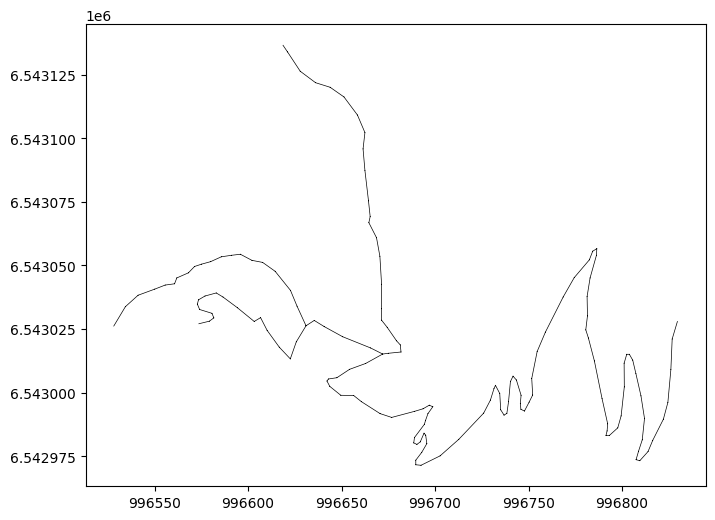

In [2]:
# WKT;link_id;source;target;direction;wkt_source;wkt_target
fmt = tkl.NetworkFormat({
       "pos_edge_id": 1,
       "pos_source": 2,
       "pos_target": 3,
       "pos_wkt": 0,
       "srid": "ENU",
       "separator": ";",
       "header": 1})
netpath = os.path.abspath(os.path.join('../../../data/network_quickstart.csv'))
network = tkl.NetworkReader.readFromFile(netpath, fmt, verbose=False)

plt.figure(figsize=(8, 6))
network.plot('k-', '', 'g-', 'r-', 0.5, plt)

print ('Number of edges=', len(network.EDGES))
print ('Number of nodes=', len(network.NODES))
print ('')

100% (1000 of 1000) |####################| Elapsed Time: 0:00:07 Time:  0:00:070000


------------------------------------------------------------
877 (87.7 %) tracks generated on network
------------------------------------------------------------


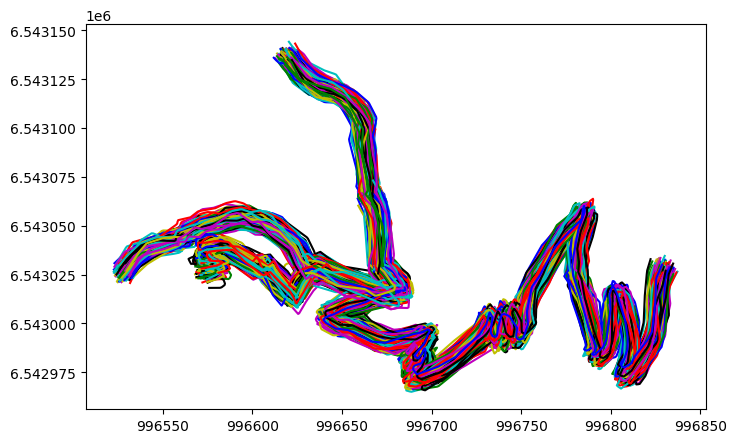

In [3]:
tkl.stochastics.seed(333)
#
noiser = tkl.NoiseProcess(amps=2.5, kernels=tkl.ExponentialKernel(80))

# generate simulated trajectories from the network 
collection = tkl.generateTracksOnNetwork(network, N=1000, p_round_trip=0.05, p_cplx_trip=0.10, resolution=1, noiser=noiser)

plt.figure(figsize=(8, 5))
collection.plot(append=plt)

## Initialisation des paramètres

L'initialisation des paramètres passe par la création du fichier de configuration. 

Lire la doc : pour en savoir plus.

### Création du fichier YAML

Créez un fichier de configuration et enregistrez-le sur le disque dur par exemple : onfig_zone1.yml

Le code ci-dessous permet de vous montrer un exemple qui sera appliqué sur le jeu de données ci-dessus et servira donc dans le pipeline.

```yaml
output:
  RESULT_PATH: "/home/glagaffe/footprint2graph/results/bauges2024/"

graph_construction:
  NUM_ITERATIONS: 1

  NB_OBS_MIN: 10
  DIST_MAX_2OBS: 50

  RESAMPLE_SIZE_GRID: 1
  RESAMPLE_SIZE_FUSION: 5

  G1_SIZE: 2
  G2_SIZE: 30

iterations:
  - SEUIL_DENSITE: 25
    SEUIL_SURFACE: 1000

    CURVE_HEIGHT: 25
    CURVE_WAVE_LENGTH: 5
    
    SEARCH: 50
    BUFFER: 20
```


La section **output** définit le chemin pour toutes les sorties données intermédiaires et données finales. 
Il est très important. Il prend l'allure d'un chemin d'un répertoire comme dans l'exemple ci-dessous:

```yaml
output:
  RESULT_PATH: /home/glagaffe/footprint2graph/results/bauges2024/
```

Le répertoire de sortie est automatiquement nettoyé au démarrage du pipeline : tous les fichiers et sous-répertoires qu’il contient sont supprimés. Les répertoires et fichiers nécessaires sont ensuite recréés progressivement au cours de l’exécution.

### Chargement du fichier de configuration pour lancer le pipeline

In [4]:
from footprint2graph import read_config

config_path = r'/home/md_vandamme/7_LIB/footprint2graph/data/config_quickstart.yml'
config = read_config(config_path)

RESPATH = config["output"]["RESULT_PATH"]

### Préparer les données

Comme indiqué dans la doc xxx il faut ....

In [5]:
# add TID attributes
for idx, track in enumerate(collection):
    track.createAnalyticalFeature('TID', idx+1)

## Lancement du pipeline

In [6]:
from footprint2graph import run_iteration

iteration_index = 1
run_iteration(iteration_index, config, collection)

-----------------------------------------------------------------
-----------------------------------------------------------------
              ITERATION  1
-----------------------------------------------------------------
-----------------------------------------------------------------
Starting segmentation and resampling...
Starting segmentation ...
    Number of tracks to resample:  877
Stage 1 finished: segmentation and resampling.
Starting rasterization and vectorization (iteration 1) 

    Loading tracks from :  resample_grid
    Number of tracks to load:  877
    Building high-resolution geometry density grid G1 :  2 m ...
    Building low-resolution contextual density grid G2 :  30 m ...
    Assigning track points to the G1 and G2 grids
    Computing G1 ...
    Computing G2 ...
    Number of neighboring cells to consider: 7
    Building contrast grid :  2 m
    Execution time (seconds): 8.431135654449463
    Finished heatmap computation.
    Starting morphological closing im

100% (291 of 291) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (287 of 287) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (333 of 333) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (318 of 318) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1417 of 1417) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (828 of 828) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (807 of 807) |######################| Elapsed Time: 0:00:00 Time:  0:00:00


    Execution time (seconds): 0.19160985946655273
    Finished morphological opening.
    Vectorizing cleaned image ...
    Extracting road surface vector features ...
        Number of polygonize features:  3
            Number of polygonize features copied:  2
    Execution time (seconds): 0.01914381980895996
    Vectorization completed.
    Smoothing polygon to remove stair-step artifacts ...
    Execution time (seconds): 0.07008147239685059
    Road surface smoothing completed.
    Starting centerline computation ...
*[2026-07-04 23:12:35.588980]  Importing polygons from: [/home/md_vandamme/7_LIB/footprint2graph/test/result1/image/road_surface_lissee_1.shp]... done

*[2026-07-04 23:12:35.625091]  Center line computation

*[2026-07-04 23:12:35.625196]  Upsampling polygon borders...

*[2026-07-04 23:12:35.632007]  Computing polygon skeleton...

*[2026-07-04 23:12:35.639024]  Filtering skeleton to form center line...

*[2026-07-04 23:12:35.642695]  Upsampling polygon borders...

*[202

100% (16 of 16) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (16 of 16) |########################| Elapsed Time: 0:00:00 Time:  0:00:00



    Finished removing hooked parts of the skeleton.
    Finished simplification of the skeleton.
Building [100 x 53] spatial index...
    Number of edges in the skeleton (after snapping): 16
    Edge count difference after snapping :  0
    Number of edges in the simplified skeleton: 15
    Number of nodes: 16
     Shortest edges limit :  50
    Number of edges in the skeleton (after removing the shortest edges): 0
    Conflation cannot be performed for node  11 ; the three incident edges are too long: 33 167 284
    Conflation cannot be performed for node  0 ; the three incident edges are too long: 33 64 122
    Edge count after conflation: 5
Stage 3 completed: adding topology to the skeleton.
Starting map-matching, aggregation, and conflation of GNSS trajectories.
    Loading network (1) ...
        Number of edges =  5
        Number of nodes =  6
        Total segment length of the network =  765.9881721624346
    Loading collection of tracks ...
        Number of tracks: 877
    

## Résultats

On va afficher le réseau de mobilité créé. Pour plus de détails sur les étapes intermédiaires, le prochaine notebook expliquera les différentes fonctionnalités.

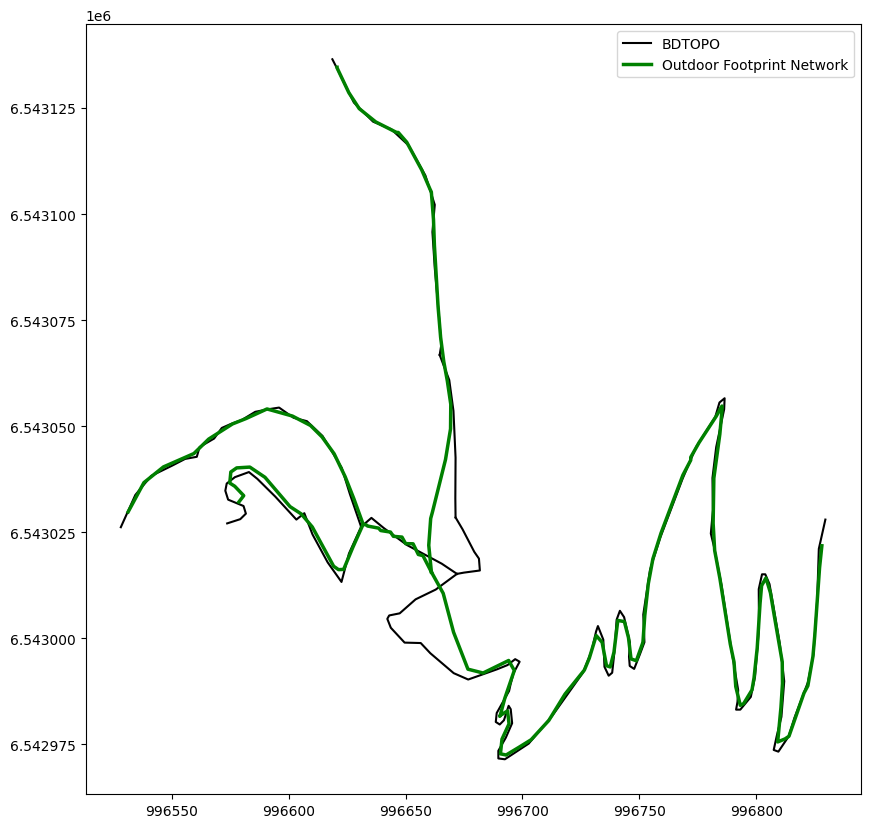

In [7]:
from footprint2graph.util.PlotRes import plotAggregation, plotConflation

plt.figure(figsize=(10, 10))
ax = plt.subplot2grid((1, 1), (0, 0))

for edge in network:
    track = edge.geom
    ax.plot(track.getX(), track.getY(), 'k-', markersize=8, label='BDTOPO')
    
plotConflation(RESPATH, ax, size=2.5, label='Outdoor Footprint Network')

# Supprime les doublons dans la légende
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())